# Building the Digital Twin

For our simulation, we will need to replicate the real world road networks that make up a given geographic region. So, we will follow this general process: 

- Define a bounding box that captures the region we are interested in analyzing.
    - These are just four coordinates that form a box around the spot on the map we want to capture.
- Query the OSM overpass API with this bounding box in order to extract an OSMNX graph which contains our road networks
- Decompose this OSMNX graph into two dataframes: nodes and edges.
    - We will use this to quickly rebuild a networkX graph when we go to use our simulation.
- Query a map provider or location service for points of interest in our bounding box.
    - These can be any arbitrary city/town features, but for our simulation, we focus on high probability "hiding spots"
    - Motels, hiking areas, public transit spots, etc
- For each point of interest, calculate the nearest node in our nodes dataset
- Mark these nodes as high priority (simple) or add the specific city features as attributes on the node (complex)
- Save individual datasets for reuse 
- Develop a function for reconstructing our networkX graph through these datasets 

In [29]:
### Relevant libraries
import requests
import numpy as np
import pandas as pd
import osmnx as ox
from math import radians, cos, sin, sqrt, atan2
from dotenv import load_dotenv
import os
import time
from sklearn.neighbors import BallTree
import networkx as nx

## Bounding Box

For our simulation we are examining the DSM metro and surrounding cities. Simple google searches help us define a bounding box by setting min/max latitude and longitude values. 

In [10]:
## latitudes
north = 42.470
south = 40.730

##longitudes
east = -92.450
west = -94.850

## Query the OSM Overpass API

We can now use the OSMNX library to quickly query the overpass API using the bounding box values. We can pass the level of granularity we want as a filter - we stick to major and minor motorways. This is already a very complex network of ~18000 edges. We can always come back and adjust this later as part of repeat experiments.

In [11]:
def GenerateGraph(north, south, east, west):
    #custom_filter = ('["highway"~"motorway|trunk|primary|secondary|tertiary|residential"]')
    custom_filter = ('["highway"~"motorway|trunk|primary|secondary|tertiary"]')
    graph = ox.graph_from_bbox((west, south, east, north),
                               custom_filter=custom_filter)

    return graph


## In order to avoid repeat queries, we should save this graph as a graphml file so that it can be read into memory quickly. 

G = GenerateGraph(north, south, east, west)
ox.save_graphml(G, "DSMMetro_demo.graphml")


C:\Users\asriv\anaconda3\lib\site-packages\osmnx\_overpass.py:267: UserWarning: This area is 15 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)


In [ ]:
## If we've already saved it locally, we can read it in here. We visualize the graph to ensure our query worked as expected.

G = ox.load_graphml("DSMMetro_demo.graphml")
ox.plot_graph(G, node_size=2, edge_linewidth=0.5)

### Expected output:

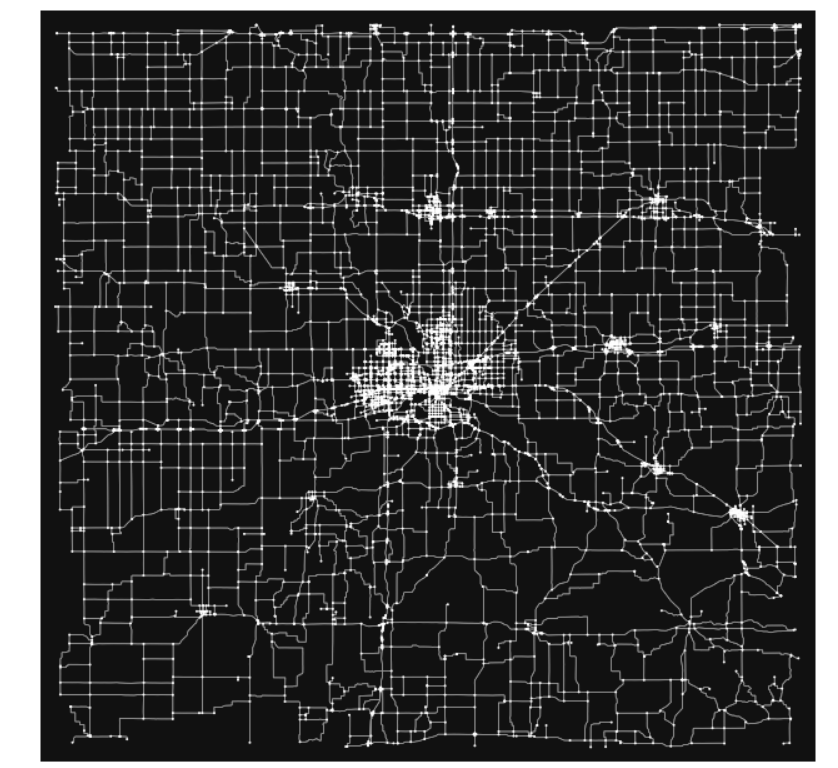

## Decompose Graph into nodes and edges dataframes

We can now break our graph into two datasets - one for the graph's nodes and one for the graph's edges. This allows us some flexibility in how we choose to extend this network graph later on. For instance, including 3rd party information to our nodes dataset allows us to quickly incorporate new data into our model. 

In [13]:
## When dealing with large areas that span multiple states, you will often have to "stitch" multiple networks together
## Its typically best practice to modify the given OSMID to include the state you are working in.
## It doesn't matter here since we are dealing with Iowa exclusively
## Look up a relevant EPSG based on your chosen state/region to avoid distortion of your network / maintain geographic fidelity.


def GraphToNetwork(graph, state_abbr = 'IA', epsg = 3417):    
    
    nodes, edges = ox.graph_to_gdfs(graph, nodes=True, edges=True)

    ## clean up nodes Dataframe
    nodes = nodes.reset_index(drop=False)[['osmid', 'x','y']]
    nodes['State'] = state_abbr
    nodes['Node'] = nodes['State'] + nodes['osmid'].astype('str')
    nodes = nodes.rename(columns={'x': 'longitude', 'y': 'latitude'})
    nodes = nodes.drop(['osmid', 'State'],axis=1)

    ## clean up edges Dataframe
    edges = edges.reset_index(drop=False)  
    edges = edges.to_crs(epsg=epsg)
    edges['length'] = edges.geometry.length
    edges = edges[['u','v','length']]
    edges['u'] = state_abbr + edges['u'].astype('str')
    edges['v'] = state_abbr + edges['v'].astype('str')
    edges['Distance_miles'] = edges['length']/1609.34
    edges['Distance_meters'] = edges['length']
    edges = edges.drop('length', axis=1)
    return nodes, edges


nodes, edges = GraphToNetwork(G)

In [14]:
## save these datasets locally for quick reference 

nodes.to_csv('DSMMetro_demo_nodes.csv')
edges.to_csv('DSMMetro_demo_edges.csv')

## Extracting Points of Interest within our Region

This is an optional step we can take to make our final model a little bit more sophisticated. We can use a map provider like Google Places to identify relevant data within our bounding box.

Since the subject of our digital twin is child abduction, we choose spots that may resemble potential hiding spots. Cheap lodging and off-the-grid spots are key locations for abductions. We can also include public transit stops, but that does introduce some complexity into our model as it assumes a suspect may be attempting to flee outside our bounding box.

Google Places has a limit of 60 results per call. So, we need to break up our bounding box into a grid of smaller boxes. We'll query each grid box indvidually and assume the first 60 results are the most relevant for that region. We can make this dynamic by splitting up each box into smaller boxes each time we hit a limit - a quadtree search is typically used here. However, as first pass POC, we'll avoid this complexity for now.

In [18]:
### Read in Authentication for Map Provider service

load_dotenv()  
google_key = os.getenv('GOOGLE_MAPS_KEY')
url = "https://places.googleapis.com/v1/places:searchNearby"

In [19]:
### Break up our bounding box into evenly spaced grid boxes
### We will make one query for each box. 
### Since Google Places has a max search radius of 50km, we will make our boxes about 25km wide, and then deduplicate our results after we merge them.

lat_step = 0.20
lon_step = 0.25

lats = np.arange(south, north, lat_step)
lons = np.arange(west, east, lon_step)


grid_points = []
for lat in lats:
    for lon in lons:
        grid_points.append((lat + lat_step / 2, lon + lon_step / 2))

print(f"Number of grid points: {len(grid_points)}")
for pt in grid_points[:5]:
    print(pt)

Number of grid points: 90
(40.83, -94.725)
(40.83, -94.475)
(40.83, -94.225)
(40.83, -93.975)
(40.83, -93.725)


In [20]:
def CallPlacesAPI(api_key, url, grid_points, radius_meters=50000):
    headers = {
        "Content-Type": "application/json",
        "X-Goog-Api-Key": api_key,
        "X-Goog-FieldMask": "*"
    }

    included_types = [
        "lodging", "apartment_complex", "apartment_building", 
        "condominium_complex", "housing_complex", "bed_and_breakfast",
        "campground", "camping_cabin", "cottage", "hotel", "motel",
        "inn", "mobile_home_park", "private_guest_room", "rv_park",
        "beach", "hiking_area"
    ]

    all_results = []

    for idx, (lat, lon) in enumerate(grid_points):
        print(f"Grid {idx+1}/{len(grid_points)}: ({lat}, {lon})")

        body = {
            "includedTypes": included_types,
            "maxResultCount": 20,
            "locationRestriction": {
                "circle": {
                    "center": {
                        "latitude": lat,
                        "longitude": lon
                    },
                    "radius": radius_meters
                }
            }
        }

        while True:
            response = requests.post(url, headers=headers, json=body)
            if response.status_code != 200:
                print(f"Error at grid {idx}: {response.status_code}: {response.text}")
                break

            data = response.json()
            places = data.get("places", [])
            print(f" → Found {len(places)} places in this page")
            all_results.extend(places)

            # Does this response have a nextPageToken?
            next_page = data.get("nextPageToken")
            if not next_page:
                break

            # If so, update body with the token and repeat
            body = {
                "nextPageToken": next_page
            }

            # Google recommends waiting a couple seconds before calling nextPage
            time.sleep(2.0)

        time.sleep(0.2)  # Be polite between grid points

    return all_results

In [22]:
### Remember - this can add up to a lot of calls depending on how granular you made your grid. 
### Its best practice to limit your search space and confirm your results look how you expect.
test = grid_points[:5]
results = CallPlacesAPI(google_key, url, test)

### Cast to dataframe for convenience
keyLocs = pd.DataFrame(results).drop_duplicates('id')
keyLocs[['latitude', 'longitude']] = keyLocs['location'].apply(
                                lambda loc: pd.Series([loc['latitude'], loc['longitude']])
                                )


### Note: This to avoid any legal trouble with Google's proprietary data, I will limit this to just 5 results. 
### That way you can see the general structure without unauthorized access to the entire dataset. 

keyLocs = keyLocs[:5]
keyLocs.to_csv('DSMMetro_demo_KeyLocations.csv')

Grid 1/5: (40.83, -94.725)
 → Found 20 places in this page
Grid 2/5: (40.83, -94.475)
 → Found 20 places in this page
Grid 3/5: (40.83, -94.225)
 → Found 20 places in this page
Grid 4/5: (40.83, -93.975)
 → Found 20 places in this page
Grid 5/5: (40.83, -93.725)
 → Found 20 places in this page


## Incorporating City Features into our Network

To keep things simple, for every location harvested from our map provider, we'll calculate the nearest node in our Nodes dataset. 

We'll consider a location relevant to a node if its within 1km of the node. We'll make use of scikit-learn's balltree algorithm to make this calculation extremely simple. 

After ascertaining the nearest node and filtering out far-away neighbors, we'll simply go through and mark each node in our Nodes dataframe as "high priority" if it shows up in our city features dataset. 

We could extract key features and apply each as an attribute to their relevant node, but we'll leave this as an opportunity to make our model more sophisticated should we need to later on. 

In [24]:
def NearestNodeFinder(places_df, nodes_df):
    places_rad = np.radians(places_df[['latitude', 'longitude']].values)
    nodes_rad = np.radians(nodes_df[['latitude', 'longitude']].values)
    tree = BallTree(nodes_rad, metric='haversine')
    distances, indices = tree.query(places_rad, k=1)
    earth_radius_m = 6371000
    distances_m = distances[:, 0] * earth_radius_m
    places_df['NearestNode'] = nodes_df.iloc[indices[:, 0]]['Node'].values
    places_df['DistanceToNode_m'] = distances_m
    return places_df


keyLocs_nodes = NearestNodeFinder(keyLocs, nodes)
highPriority_nodes = list(set(keyLocs_nodes[keyLocs_nodes['DistanceToNode_m'] < 1000]['NearestNode']))


### update our Nodes dataframe

nodes['isHighPriority'] = [True if i in highPriority_nodes else False for i in nodes['Node']]

### Saving our datasets 

We'll use these datasets elsewhere in our build. We'll organize their respective saves here for future reference. 

In [25]:
ox.save_graphml(G, "DSMMetro_demo.graphml")
nodes.to_csv('DSMMetro_demo_nodes.csv')
edges.to_csv('DSMMetro_demo_edges.csv')
keyLocs.to_csv('DSMMetro_demo_KeyLocations.csv')

## Recreating our Graph in NetworkX 

While we don't really need this here, it might be convenient to define a way for us to build our graph out as a NetworkX object should we need to use it sooner than later. 

NetworkX offers us useful graph objects with a ton of handy built-in capabilities such as route-finding, expanding nearest-neighbors, or performing route-wise aggregations if we are suspending a lot of data on each node. 

In [26]:
def BuildNetworkXGraph(nodes, edges):
    G = nx.Graph()
    for _, row in nodes.iterrows():
        G.add_node(row['Node'], **row.drop('Node').to_dict())
        
    for _, row in edges.iterrows():
        G.add_edge(row['u'], row['v'], **row.drop(['u', 'v']).to_dict())
        
    return G

In [30]:
### If we want to verify our graph is loaded as expected, we can visualize it. I like plotly for this. 

import plotly.graph_objects as go

def VisualizeGraph(G):
    
    edge_x = []
    edge_y = []
    for edge in G.edges():
        x0, y0 = G.nodes[edge[0]]['longitude'], G.nodes[edge[0]]['latitude']
        x1, y1 = G.nodes[edge[1]]['longitude'], G.nodes[edge[1]]['latitude']
        edge_x += [x0, x1, None]
        edge_y += [y0, y1, None]
    
    edge_trace = go.Scatter(
        x=edge_x, y=edge_y,
        mode='lines',
        line=dict(width=1, color='black'),
        hoverinfo='none'
    )
    
    # Extract nodes
    node_x = []
    node_y = []
    node_text = []
    for node in G.nodes():
        node_x.append(G.nodes[node]['longitude'])
        node_y.append(G.nodes[node]['latitude'])
        node_text.append(f'Node {node}')
    
    node_trace = go.Scatter(
        x=node_x, y=node_y,
        mode='markers',
        marker=dict(size=1, color='black')
    )
    
    fig = go.Figure(
        data=[edge_trace, node_trace],
        layout=go.Layout(
            title='Network Graph with Latitude and Longitude',
            showlegend=False,
            hovermode='closest',
            xaxis=dict(title='Longitude'),
            yaxis=dict(title='Latitude'),
            width=1000,  # Width in pixels
            height=1000  # Height in pixels
        )
    )
    fig.show()
    return None

In [ ]:
edges = pd.read_csv('DSMMetro_demo_edges.csv')
nodes = pd.read_csv('DSMMetro_demo_nodes.csv')
nodes = nodes[['Node', 'longitude', 'latitude', 'isHighPriority']]

G = BuildNetworkXGraph(nodes,edges)

_ = VisualizeGraph(G)

## Expected output: 

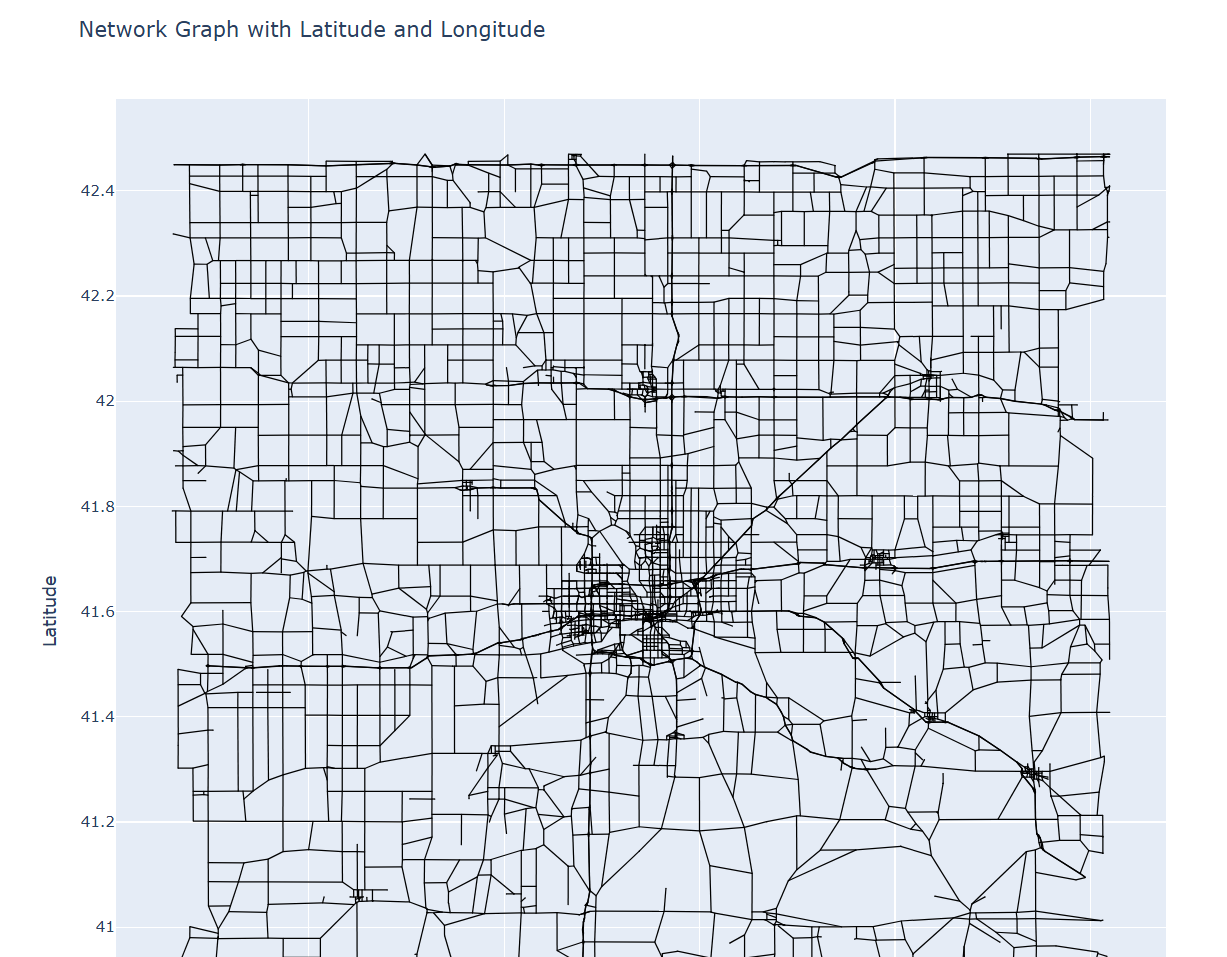